In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

import gseapy as gp
from gseapy import dotplot

## Load & Align Data

In [2]:
# Training metadata + ML feature matrix (for sample names)
train_meta = pd.read_csv("../datasets/csv_files/ml_datasets/train_data.csv")

# Multivariate Cox risk scores — aligned to the merge(clinical, expr).dropna() subset
risk_df = pd.read_csv("../datasets/csv_files/risk_scores_train.csv")

# Align by sample_name (risk_df covers only the 101 samples with complete
# clinical + expression data; train_data.csv has 104 rows before that merge)
if "sample_name" in risk_df.columns:
    sample_group = dict(zip(risk_df["sample_name"], risk_df["risk_group"]))
else:
    # Fallback for CSVs generated before sample_name was added:
    # replicate the merge used in mutivariate_cox.ipynb to get the same subset
    expr_raw_tmp = pd.read_csv("../datasets/csv_files/expression_matrix_train.csv", index_col=0)
    expr_samples = set(expr_raw_tmp.columns) - {"gene_symbol"}
    train_clean = (
        train_meta[train_meta["sample_name"].isin(expr_samples)]
        .dropna()
        .reset_index(drop=True)
    )
    assert len(train_clean) == len(risk_df), (
        f"Row count mismatch after expr filter: train_clean={len(train_clean)}, risk_df={len(risk_df)}"
    )
    sample_group = dict(zip(train_clean["sample_name"], risk_df["risk_group"]))

print(f"Training samples aligned : {len(sample_group)}")
print("Risk group counts        :", risk_df["risk_group"].value_counts().to_dict())
print("Cutoff (median risk score):", risk_df["risk_score"].median().round(4))

Training samples aligned : 101
Risk group counts        : {'High Risk': 51, 'Low Risk': 50}
Cutoff (median risk score): 5.0316


## Prepare Expression Matrix

Use the full pre-normalised expression matrix (all genes) for maximal KEGG pathway coverage, rather than the 263-gene DEG feature subset.

In [3]:
# Full expression matrix: rows = genes, columns = gene_symbol + sample IDs
expr_raw = pd.read_csv("../datasets/csv_files/expression_matrix_train.csv",
                        index_col=0)          # drop unnamed row index

# Set gene symbol as row index
expr_raw = expr_raw.set_index("gene_symbol")

# Keep only training samples that have a risk group
train_samples = [c for c in expr_raw.columns if c in sample_group]
expr_train    = expr_raw[train_samples]

# Class vector: must be in the same order as expr_train columns
cls = [sample_group[s] for s in train_samples]

n_high = cls.count("High Risk")
n_low  = cls.count("Low Risk")
print(f"Expression matrix       : {expr_train.shape[0]:,} genes x {expr_train.shape[1]} samples")
print(f"High Risk / Low Risk    : {n_high} / {n_low}")
print(f"Positive phenotype (pos): High Risk")

KeyError: "None of ['gene_symbol'] are in the columns"

## GSEA — Training Set

Runs GSEA (`gseapy.gsea`) with phenotype permutation, replicating the paper's GSEA v4 analysis:
- Gene set: **KEGG_2021_Human** (equivalent to c2.cp.kegg from MSigDB)
- Ranking metric: signal-to-noise ratio
- Permutations: 1 000 phenotype permutations
- Significance threshold: **FDR < 25 %** (Benjamini–Hochberg)

In [ ]:
gs_res = gp.gsea(
    data            = expr_train,          # genes x samples DataFrame
    gene_sets       = "KEGG_2021_Human",   # KEGG pathway library
    cls             = cls,                 # ["High Risk", "Low Risk", ...]
    permutation_type= "phenotype",         # phenotype permutation (>=15 samples)
    permutation_num = 1000,
    outdir          = None,                # do not write to disk
    method          = "signal_to_noise",   # standard GSEA ranking metric
    min_size        = 15,
    max_size        = 500,
    threads         = 4,
    seed            = 42,
    verbose         = False,
)
print("GSEA complete.")
print(f"Gene sets tested: {len(gs_res.res2d)}")

GSEA complete.
Gene sets tested: 304


## Results (FDR < 25 %)

In [ ]:
res = gs_res.res2d.copy()

# Normalise column names across gseapy versions
col_map = {
    "NOM p-val": "pval",  "FDR q-val": "fdr",  "NES": "nes",
    "ES": "es",           "Lead_genes": "lead_genes",
    "Tag %": "tag_pct",   "Gene %": "gene_pct",
}
res = res.rename(columns={k: v for k, v in col_map.items() if k in res.columns})

# Coerce numeric
for c in ["es", "nes", "pval", "fdr"]:
    if c in res.columns:
        res[c] = pd.to_numeric(res[c], errors="coerce")

# Filter FDR < 0.25
sig = res[res["fdr"] < 0.25].sort_values("nes", ascending=False).reset_index(drop=True)

print(f"Total pathways tested    : {len(res)}")
print(f"Significant (FDR < 25%) : {len(sig)}")
print(f"  Enriched in High Risk  : {(sig['nes'] > 0).sum()}")
print(f"  Enriched in Low Risk   : {(sig['nes'] < 0).sum()}")

display_cols = [c for c in ["Term", "nes", "es", "pval", "fdr", "tag_pct", "lead_genes"]
                if c in sig.columns]
display(sig[display_cols].round(4))

Total pathways tested    : 304
Significant (FDR < 25%) : 40
  Enriched in High Risk  : 0
  Enriched in Low Risk   : 40


,Term,nes,es,pval,fdr,tag_pct,lead_genes
0,mTOR signaling pathway,-1.5469,-0.3884,0.0101,0.2374,64/147,RPS6KB2;SLC3A2;SLC7A5;LAMTOR2;AKT1S1;SEC13;TBC...
1,Homologous recombination,-1.5542,-0.5376,0.0451,0.2325,23/37,POLD2;BABAM1;RAD51;POLD1;EME1;RPA3;SSBP1;RAD51...
2,Oocyte meiosis,-1.5634,-0.4210,0.0320,0.2229,41/113,AURKA;PTTG1;CDC20;MAD2L1;CCNB1;ESPL1;MAPK13;YW...
3,Cellular senescence,-1.5676,-0.4249,0.0301,0.2228,71/152,MYBL2;FOXM1;CDK4;CCNB1;MAPK13;SQSTM1;CHEK1;EIF...
4,RNA transport,-1.5810,-0.5566,0.0263,0.2075,68/145,NXT1;XPO5;SUMO3;GEMIN6;SEC13;POP7;EIF2B3;NUP15...
5,Pentose phosphate pathway,-1.5870,-0.5175,0.0518,0.2042,10/29,GPI;TALDO1;ALDOA;PFKL;PRPS1;G6PD;TKT;ALDOC;PFK...
6,Aminoacyl-tRNA biosynthesis,-1.5894,-0.6160,0.0373,0.2064,14/23,FARSA;FARS2;DARS2;YARS2;SARS2;NARS2;MTFMT;PARS...
7,Glycosphingolipid biosynthesis,-1.6023,-0.4736,0.0315,0.1965,16/43,ST3GAL4;B4GALT3;B3GALNT1;B4GALT4;FUT1;B4GALT2;...
8,Ribosome,-1.6106,-0.6686,0.0457,0.1909,73/112,MRPL21;MRPS12;MRPL14;MRPL12;MRPS7;MRPS18A;MRPL...
9,Various types of N-glycan biosynthesis,-1.6153,-0.5396,0.0237,0.1909,19/36,ALG3;ALG1;MGAT4B;RPN1;DDOST;B4GALT3;RPN2;DAD1;...


## Enrichment Score Plots

Running enrichment curves for the top 5 significant pathways (by absolute NES).

Saved: gsea_top_enriched_curves.png


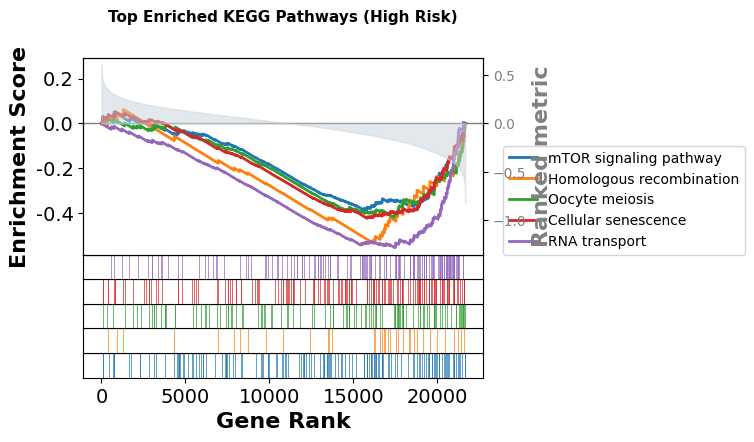

In [ ]:
# Top 5 pathways by absolute NES
if len(sig) > 0:
    top_terms = sig.nlargest(min(5, len(sig)), "nes")["Term"].tolist()
    axs = gs_res.plot(
        terms          = top_terms,
        show_ranking   = True,
        legend_kws     = {"loc": (1.05, 0)},
        figsize        = (5, 4),
    )
    plt.suptitle("Top Enriched KEGG Pathways (High Risk)", fontsize=11,
                 fontweight="bold", y=1.02)
    plt.savefig("../visuals/gsea_top_enriched_curves.png", dpi=150,
                bbox_inches="tight")
    print("Saved: gsea_top_enriched_curves.png")
    plt.show()
else:
    print("No significant pathways at FDR < 25%.")

Saved: gsea_top_protective_curves.png


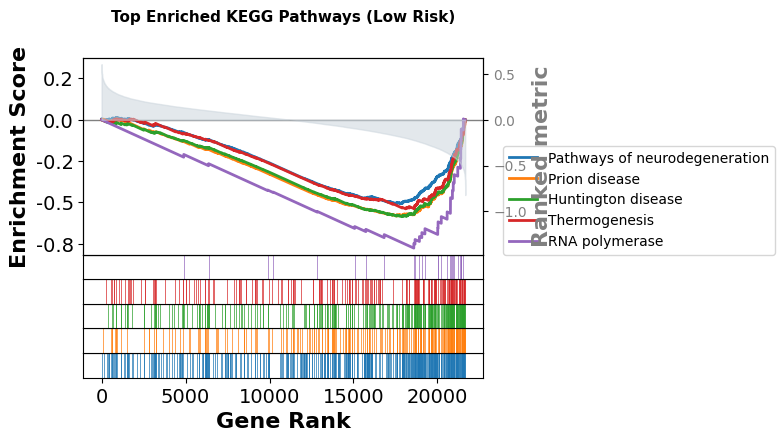

In [ ]:
# Bottom 5 pathways (enriched in Low Risk)
if (sig["nes"] < 0).any():
    bot_terms = sig.nsmallest(min(5, (sig["nes"] < 0).sum()), "nes")["Term"].tolist()
    axs = gs_res.plot(
        terms        = bot_terms,
        show_ranking = True,
        legend_kws   = {"loc": (1.05, 0)},
        figsize      = (5, 4),
    )
    plt.suptitle("Top Enriched KEGG Pathways (Low Risk)", fontsize=11,
                 fontweight="bold", y=1.02)
    plt.savefig("../visuals/gsea_top_protective_curves.png", dpi=150,
                bbox_inches="tight")
    print("Saved: gsea_top_protective_curves.png")
    plt.show()

## Dot Plot — Significant KEGG Pathways

Saved: gsea_dotplot.png


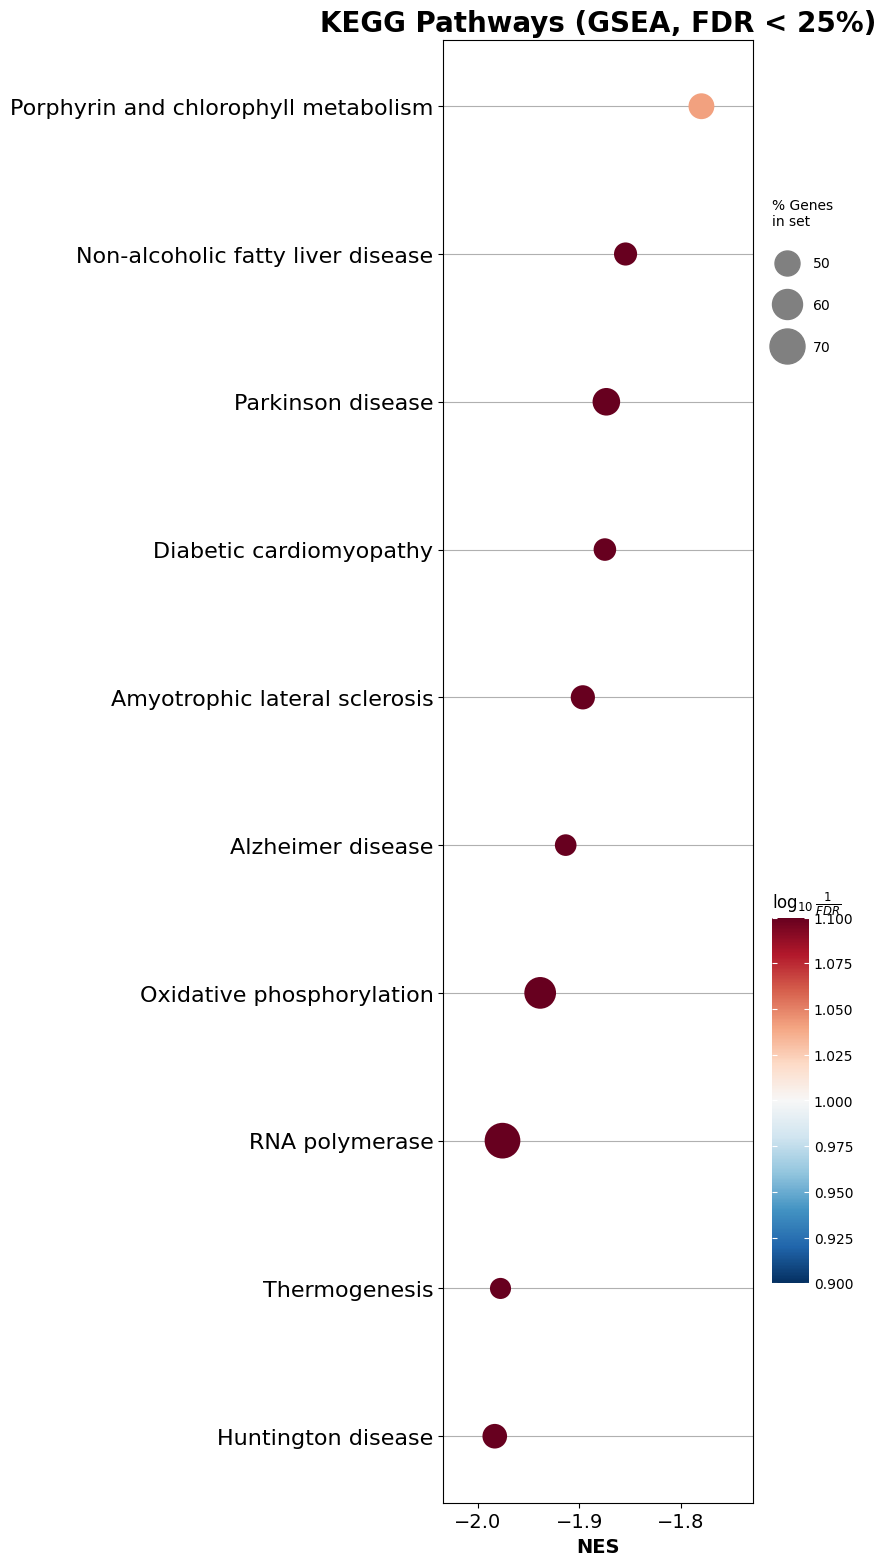

In [ ]:
if len(sig) > 0:
    ax = dotplot(
        gs_res.res2d,
        column  = "FDR q-val" if "FDR q-val" in gs_res.res2d.columns else "fdr",
        title   = "KEGG Pathways (GSEA, FDR < 25%)",
        cmap    = plt.cm.RdBu_r,
        size    = 6,
        figsize = (5, max(4, len(sig) * 0.45 + 1)),
        cutoff  = 0.25,
        show_ring = False,
    )
    plt.savefig("../visuals/gsea_dotplot.png", dpi=150, bbox_inches="tight")
    print("Saved: gsea_dotplot.png")
    plt.show()

## NES Bar Chart

Horizontal bar chart of normalised enrichment scores for significant pathways.
Red = enriched in High Risk; Blue = enriched in Low Risk.

Saved: gsea_nes_barplot.png


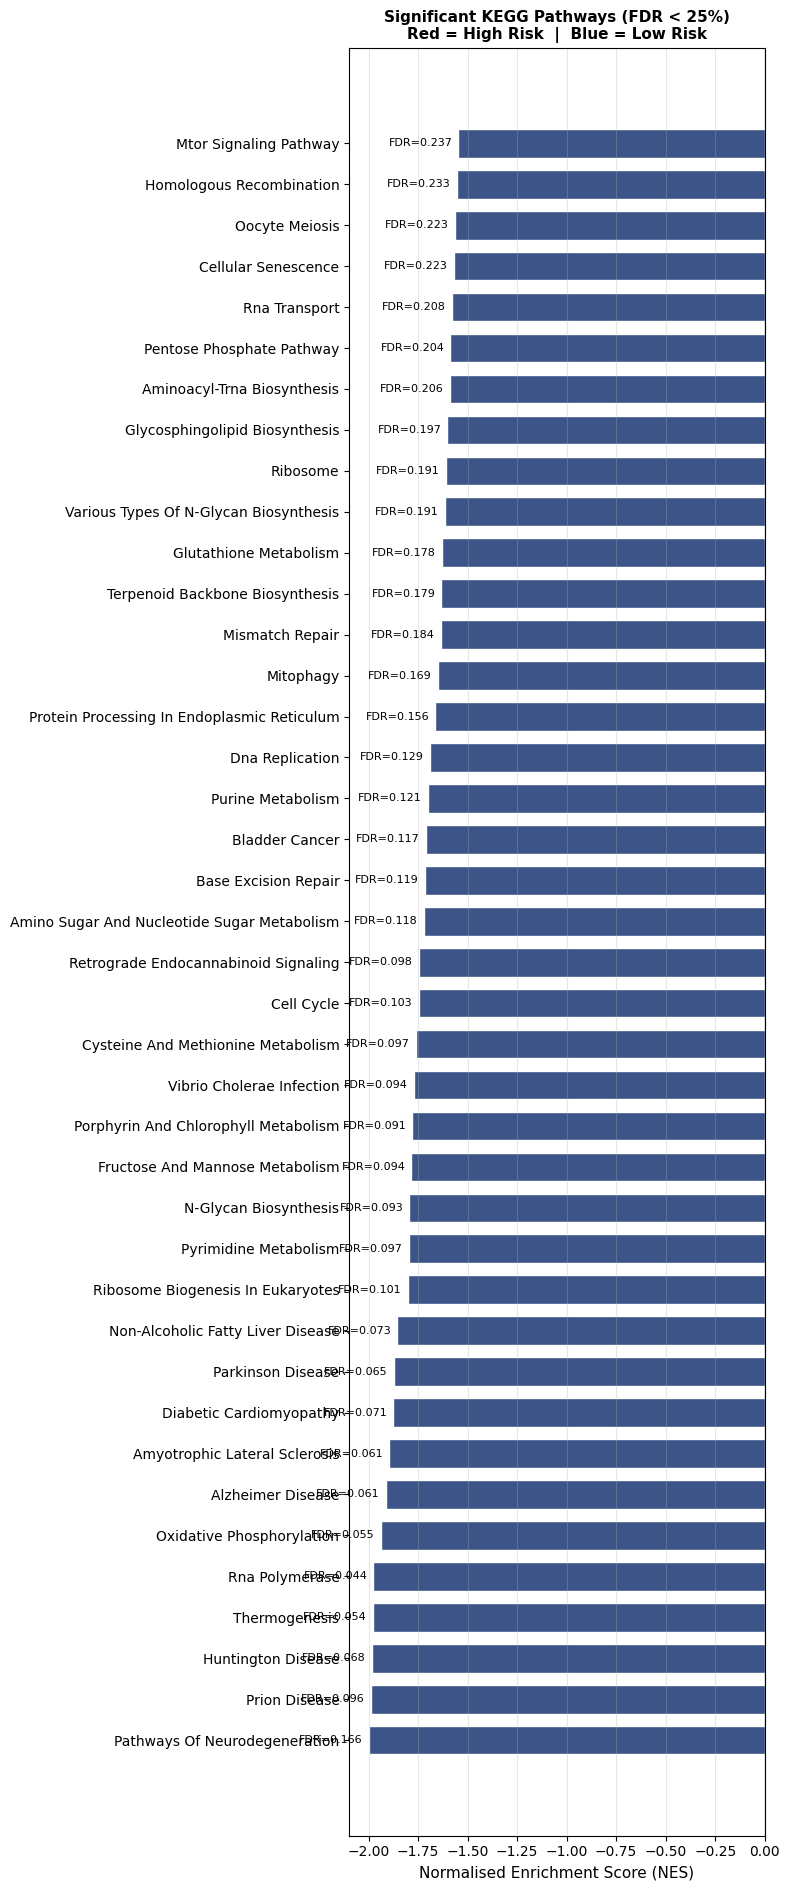

In [ ]:
if len(sig) > 0:
    # Clean up pathway names (remove "Homo sapiens ..." suffixes)
    import re
    def clean_name(name):
        name = re.sub(r" Homo sapiens.*", "", name)
        name = name.replace("_", " ").title()
        return name[:60] + ("..." if len(name) > 60 else "")

    plot_df = sig[["Term", "nes", "fdr"]].copy()
    plot_df["label"] = plot_df["Term"].apply(clean_name)
    plot_df = plot_df.sort_values("nes")

    colors = ["#3C5488" if v < 0 else "#E64B35" for v in plot_df["nes"]]

    fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.45 + 1)))
    bars = ax.barh(plot_df["label"], plot_df["nes"],
                   color=colors, edgecolor="white", height=0.7)

    # FDR labels
    for bar, fdr_val in zip(bars, plot_df["fdr"]):
        x = bar.get_width()
        offset = 0.03 if x >= 0 else -0.03
        ha = "left" if x >= 0 else "right"
        ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
                f"FDR={fdr_val:.3f}", va="center", ha=ha, fontsize=8)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Normalised Enrichment Score (NES)", fontsize=11)
    ax.set_title("Significant KEGG Pathways (FDR < 25%)\n"
                 "Red = High Risk  |  Blue = Low Risk", fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("../visuals/gsea_nes_barplot.png", dpi=150, bbox_inches="tight")
    print("Saved: gsea_nes_barplot.png")
    plt.show()

## Leading-Edge Gene Heatmap

Expression heatmap of leading-edge genes from the most significant pathway.

Saved: gsea_leading_edge_heatmap.png  (64 genes)


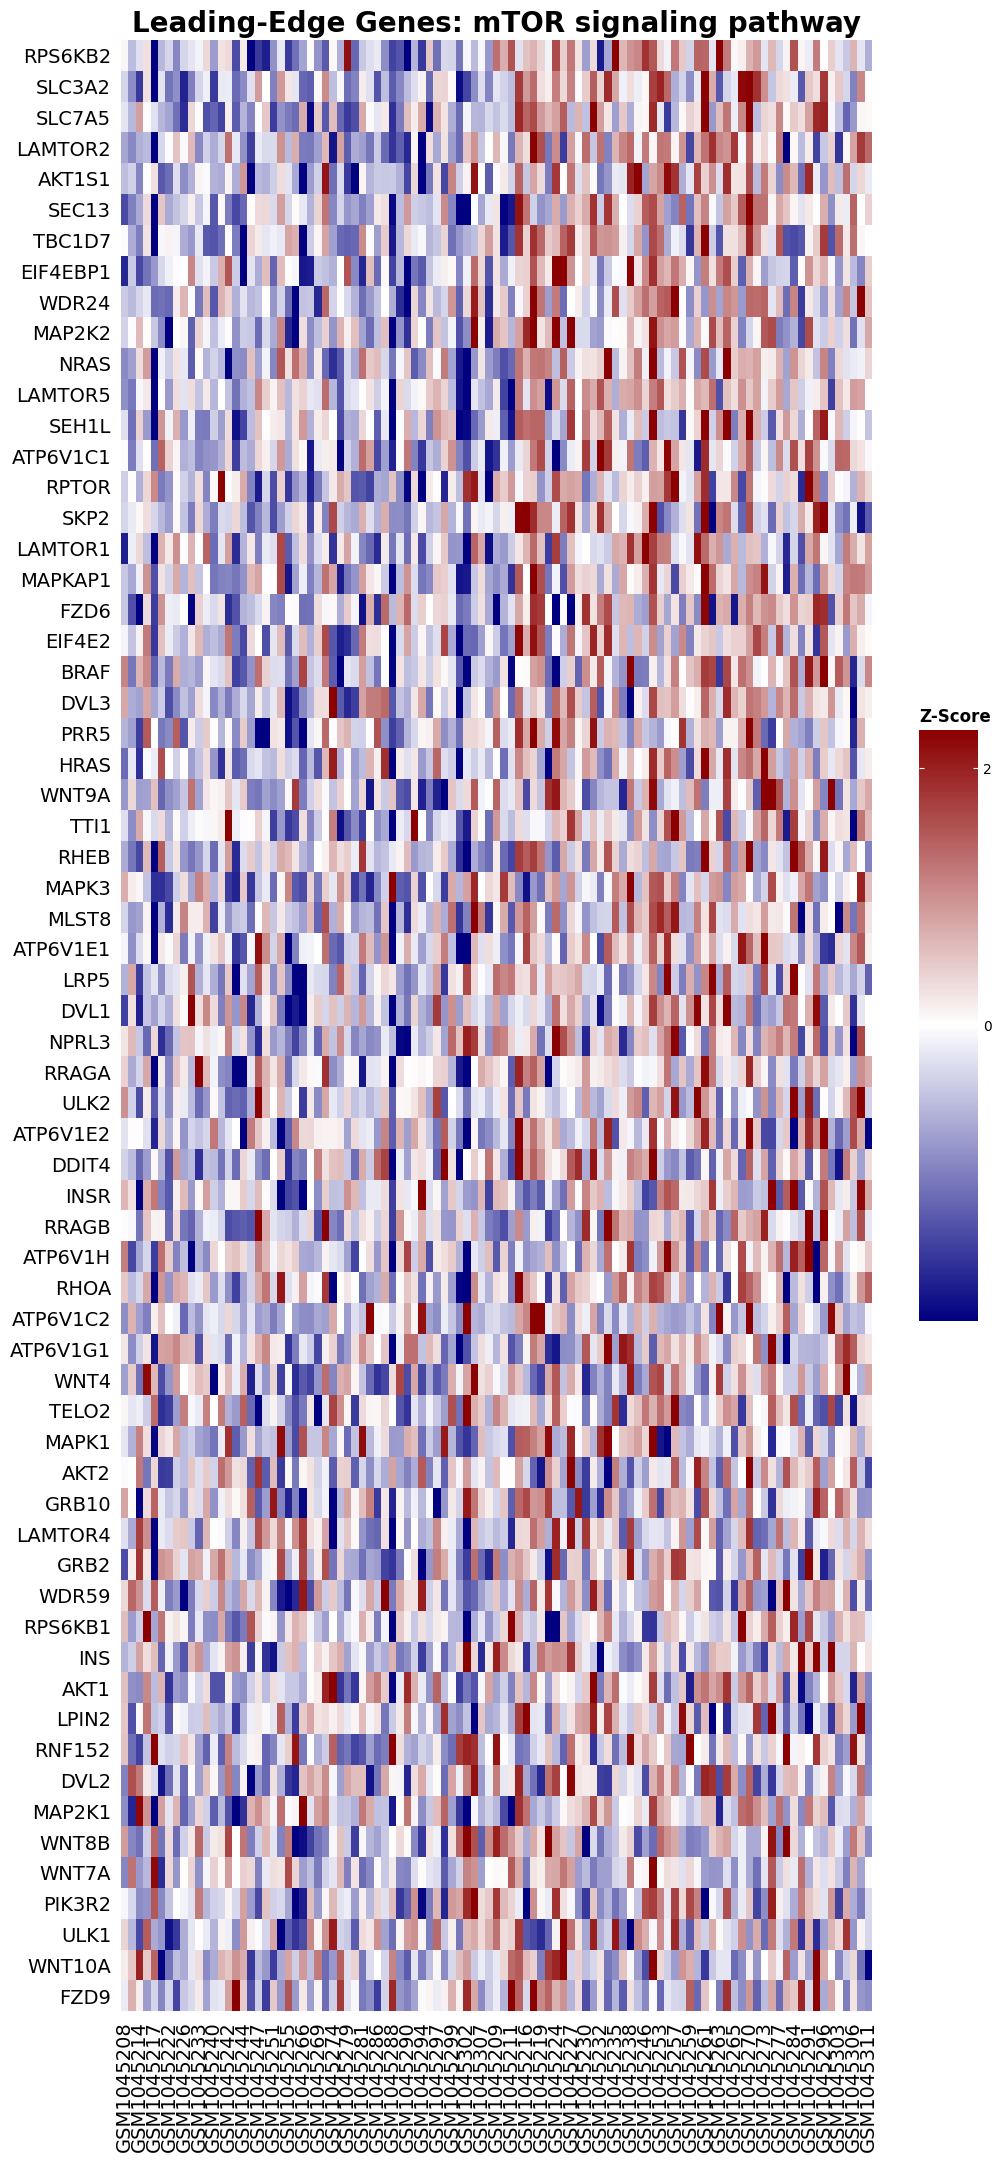

In [ ]:
from gseapy import heatmap

if len(sig) > 0:
    # Use the top pathway by NES
    top_term = sig.iloc[0]["Term"]
    lead_col = "lead_genes" if "lead_genes" in sig.columns else "Lead_genes"
    lead_genes_str = sig.iloc[0][lead_col]

    if isinstance(lead_genes_str, str) and lead_genes_str:
        lead_genes = [g.strip() for g in lead_genes_str.split(";") if g.strip()]
        # Filter to genes present in heatmat
        available = [g for g in lead_genes if g in gs_res.heatmat.index]

        if available:
            import re
            title = re.sub(r" Homo sapiens.*", "", top_term)[:55]
            ax = heatmap(
                df      = gs_res.heatmat.loc[available],
                z_score = 0,
                title   = f"Leading-Edge Genes: {title}",
                figsize = (max(10, len(train_samples) * 0.12), max(4, len(available) * 0.4)),
            )
            plt.savefig("../visuals/gsea_leading_edge_heatmap.png", dpi=150,
                        bbox_inches="tight")
            print(f"Saved: gsea_leading_edge_heatmap.png  ({len(available)} genes)")
            plt.show()
        else:
            print("No leading-edge genes found in heatmat index.")
    else:
        print("No leading-edge genes available for the top pathway.")